# Task 05 – Model Training and Optimization

Train, tune, monitor, and save GCN and GraphSAGE.

In [2]:
!pip install -q torch-geometric ogb streamlit

In [3]:
import os
# Compatibility fix for trusted PyG objects downloaded by the official OGB package on PyTorch 2.6+.
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/OGBN_Arxiv_Project')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'

for folder in [PROJECT_ROOT, RESULTS_ROOT, MODELS_DIR, SRC_DIR, ARTIFACTS_DIR,
               PROJECT_ROOT / 'notebooks', PROJECT_ROOT / 'visualizations',
               PROJECT_ROOT / 'dashboard', PROJECT_ROOT / 'report',
               PROJECT_ROOT / 'presentation', PROJECT_ROOT / 'video']:
    folder.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/OGBN_Arxiv_Project


In [4]:
# Common reproducibility settings
import warnings
import random
import numpy as np

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [5]:
# Libraries required for Task 05
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch

OUTPUT = RESULTS_ROOT / 'task05_training'
OUTPUT.mkdir(parents=True, exist_ok=True)

## 5.1 Prepared Graph on the Computing Device

Moves node features, labels, graph edges, and split indices to the same device before model optimization begins.

In [6]:
import torch
from ogb.nodeproppred import PygNodePropPredDataset

# Define the computing device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the OGBN-Arxiv dataset for Task 03 prepared data
# Assuming PROJECT_ROOT is defined from a previous cell
dataset = PygNodePropPredDataset(name='ogbn-arxiv', root=str(PROJECT_ROOT / 'dataset'))
data = dataset[0] # Get the first (and only) graph in the dataset

# Extract features, labels, and edge_index
x = data.x
y = data.y.squeeze() # Ensure y is 1D if it's originally 2D with a single column
edge_index = data.edge_index

# Get split indices
split_idx = dataset.get_idx_split()
train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

# Move the Task 03 prepared data to the selected device once.
x_device = x.to(DEVICE)
y_device = y.to(DEVICE)
edge_device = edge_index.to(DEVICE)

train_device = train_idx.to(DEVICE)
valid_device = valid_idx.to(DEVICE)
test_device = test_idx.to(DEVICE)

print("Features:", x_device.shape)
print("Edges:", edge_device.shape)
print("Device:", DEVICE)

Features: torch.Size([169343, 128])
Edges: torch.Size([2, 1166243])
Device: cpu


## 5.2 Split Accuracy Function

Defines a reusable evaluation function that measures prediction accuracy on a selected group of nodes.

In [7]:
@torch.no_grad()
def calculate_split_accuracy(model, node_indices):
    """
    Calculate classification accuracy for one dataset split.

    Parameters
    ----------
    model:
        Trained GNN model.
    node_indices:
        Indices belonging to training, validation or test split.
    """

    model.eval()

    logits = model(
        x_device,
        edge_device
    )

    predictions = logits[node_indices].argmax(dim=1)

    accuracy = (
        predictions == y_device[node_indices]
    ).float().mean().item()

    return accuracy

## 5.3 Hyperparameter Selection Strategy

The candidate configurations vary important training choices such as learning rate and dropout. Validation accuracy selects the better configuration; the test set is reserved for final evaluation and is not used for tuning.

## 5.4 Training and Early-Stopping Function

Defines optimization, loss calculation, validation monitoring, checkpoint selection, and early stopping in one consistent training workflow.

In [8]:
def train_model(
    model_name,
    hidden_dim,
    learning_rate,
    dropout,
    max_epochs=300,
    patience=40
):
    """Train one model and retain its best validation checkpoint."""

    # Select the model architecture
    if model_name == "GCN":
        model = GCN(
            input_dim=F_DIM,
            hidden_dim=hidden_dim,
            output_dim=NUM_CLASSES,
            dropout=dropout
        )

    elif model_name == "GraphSAGE":
        model = GraphSAGE(
            input_dim=F_DIM,
            hidden_dim=hidden_dim,
            output_dim=NUM_CLASSES,
            dropout=dropout
        )

    else:
        raise ValueError("Unknown model name")

    model = model.to(DEVICE)

    # Multi-class classification loss
    loss_function = torch.nn.CrossEntropyLoss(
        label_smoothing=0.05
    )

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4
    )

    # Reduce learning rate when validation improvement stops
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    best_validation = -1.0
    best_state = None
    best_epoch = 0
    waiting = 0
    history = []

    start_time = time.perf_counter()

    for epoch in range(1, max_epochs + 1):

        # Training
        model.train()
        optimizer.zero_grad()

        output = model(
            x_device,
            edge_device
        )

        loss = loss_function(
            output[train_device],
            y_device[train_device]
        )

        loss.backward()

        # Prevent excessively large gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=2.0
        )

        optimizer.step()

        # Calculate training accuracy from current output
        with torch.no_grad():
            train_predictions = output[
                train_device
            ].argmax(dim=1)

            train_accuracy = (
                train_predictions ==
                y_device[train_device]
            ).float().mean().item()

        # Calculate validation accuracy
        validation_accuracy = calculate_split_accuracy(
            model,
            valid_device
        )

        scheduler.step(validation_accuracy)

        history.append({
            "epoch": epoch,
            "loss": loss.item(),
            "train_accuracy": train_accuracy,
            "validation_accuracy": validation_accuracy,
            "learning_rate":
                optimizer.param_groups[0]["lr"]
        })

        # Save the best validation checkpoint
        if validation_accuracy > best_validation:
            best_validation = validation_accuracy
            best_state = copy.deepcopy(
                model.state_dict()
            )
            best_epoch = epoch
            waiting = 0
        else:
            waiting += 1

        # Display training progress
        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {loss.item():.4f} | "
                f"Train {train_accuracy:.4f} | "
                f"Validation {validation_accuracy:.4f} | "
                f"LR {optimizer.param_groups[0]['lr']:.6f}"
            )

        # Stop when validation no longer improves
        if waiting >= patience:
            print(
                "Early stopping at epoch",
                epoch
            )
            break

    # Restore the best checkpoint
    model.load_state_dict(best_state)

    training_seconds = (
        time.perf_counter() - start_time
    )

    print(
        "Best validation accuracy:",
        round(best_validation, 4)
    )

    print("Best epoch:", best_epoch)

    return {
        "model": model,
        "history": pd.DataFrame(history),
        "best_validation_accuracy":
            best_validation,
        "best_epoch":
            best_epoch,
        "training_seconds":
            training_seconds
    }

## 5.5 Candidate Hyperparameter Configurations

Lists the hidden size, learning rate, dropout, epoch limit, and patience settings compared during model tuning.

In [9]:
configs = [
    {
        "hidden_dim": 128,
        "learning_rate": 0.01,
        "dropout": 0.5,
        "max_epochs": 300,
        "patience": 40
    },
    {
        "hidden_dim": 256,
        "learning_rate": 0.01,
        "dropout": 0.5,
        "max_epochs": 300,
        "patience": 40
    },
    {
        "hidden_dim": 256,
        "learning_rate": 0.005,
        "dropout": 0.4,
        "max_epochs": 300,
        "patience": 40
    }
]

display(pd.DataFrame(configs))

,hidden_dim,learning_rate,dropout,max_epochs,patience
0,128,0.010,0.5,300,40
1,256,0.010,0.5,300,40
2,256,0.005,0.4,300,40


## 5.6 Training Both Architectures

Trains GCN and GraphSAGE under each candidate configuration and retains the checkpoint with the strongest validation accuracy for each architecture.

In [10]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, SAGEConv

# Define feature dimension and number of classes from loaded data
# x_device and y_device are expected to be available from cell HvRCoQ6z7IGG
F_DIM = x_device.shape[1]
NUM_CLASSES = y_device.unique().size(0)

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x


configs = [
    {
        'hidden_dim': 128,
        'learning_rate': 0.01,
        'dropout': 0.5,
        'max_epochs': 150,
        'patience': 20
    },
    {
        'hidden_dim': 256,
        'learning_rate': 0.005,
        'dropout': 0.4,
        'max_epochs': 150,
        'patience': 20
    }
]

best_models = {}
best_histories = {}
best_configurations = {}
tuning_rows = []

for model_name in ['GCN', 'GraphSAGE']:
    selected = None
    selected_config = None

    for run_number, config in enumerate(configs, start=1):
        print(f'\n{model_name} - Configuration {run_number}')
        result = train_model(model_name=model_name, **config)

        tuning_rows.append({
            'model': model_name,
            'run': run_number,
            **config,
            'status': 'Completed',
            'best_validation_accuracy': result['best_validation_accuracy'],
            'best_epoch': result['best_epoch'],
            'training_seconds': result['training_seconds']
        })

        if selected is None or result['best_validation_accuracy'] > selected['best_validation_accuracy']:
            selected = result
            selected_config = config.copy()

    best_models[model_name] = selected['model']
    best_histories[model_name] = selected['history']
    best_configurations[model_name] = selected_config

    torch.save(
        {
            'model_state': selected['model'].state_dict(),
            'config': selected_config,
            'validation_accuracy': selected['best_validation_accuracy']
        },
        MODELS_DIR / f'best_{model_name.lower()}.pt'
    )

    selected['history'].to_csv(
        OUTPUT / f'{model_name.lower()}_training_history.csv',
        index=False
    )

    print('Selected configuration:', selected_config)
    print('Best validation accuracy:', round(selected['best_validation_accuracy'], 4))


GCN - Configuration 1
Epoch 001 | Loss 3.8655 | Train 0.0062 | Validation 0.0847 | LR 0.010000
Epoch 010 | Loss 2.8262 | Train 0.3105 | Validation 0.3911 | LR 0.010000
Epoch 020 | Loss 2.4071 | Train 0.4274 | Validation 0.4784 | LR 0.010000
Epoch 030 | Loss 2.1892 | Train 0.4782 | Validation 0.5150 | LR 0.010000
Epoch 040 | Loss 2.0639 | Train 0.5098 | Validation 0.5337 | LR 0.010000
Epoch 050 | Loss 1.9879 | Train 0.5281 | Validation 0.5460 | LR 0.010000
Epoch 060 | Loss 1.9393 | Train 0.5406 | Validation 0.5580 | LR 0.010000
Epoch 070 | Loss 1.9072 | Train 0.5476 | Validation 0.5636 | LR 0.010000
Epoch 080 | Loss 1.8834 | Train 0.5546 | Validation 0.5695 | LR 0.010000
Epoch 090 | Loss 1.8681 | Train 0.5571 | Validation 0.5722 | LR 0.010000
Epoch 100 | Loss 1.8546 | Train 0.5618 | Validation 0.5751 | LR 0.010000
Epoch 110 | Loss 1.8419 | Train 0.5639 | Validation 0.5751 | LR 0.010000
Epoch 120 | Loss 1.8341 | Train 0.5666 | Validation 0.5755 | LR 0.010000
Epoch 130 | Loss 1.8252 | Tr

## 5.7 Hyperparameter and Optimization Results

The table compares the tested learning rates, hidden dimensions, and dropout rates. Validation accuracy selects the final configuration; the test set is not used during tuning.

In [11]:
tuning_results = pd.DataFrame(tuning_rows)

tuning_results = tuning_results.sort_values(
    by="best_validation_accuracy",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(tuning_results)

tuning_results.to_csv(
    OUTPUT / "hyperparameter_results.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT / "hyperparameter_results.csv"
)

,model,run,hidden_dim,learning_rate,dropout,max_epochs,patience,status,best_validation_accuracy,best_epoch,training_seconds
0,GraphSAGE,2,256,0.005,0.4,150,20,Completed,0.602671,150,1970.145196
1,GraphSAGE,1,128,0.010,0.5,150,20,Completed,0.595557,145,1305.590550
2,GCN,2,256,0.005,0.4,150,20,Completed,0.584885,149,1956.539463
3,GCN,1,128,0.010,0.5,150,20,Completed,0.580858,145,1199.418011


Saved: /content/drive/MyDrive/OGBN_Arxiv_Project/results/task05_training/hyperparameter_results.csv


## 5.8 Training and Validation Curves

These curves monitor learning progress and show whether the selected models begin to overfit.

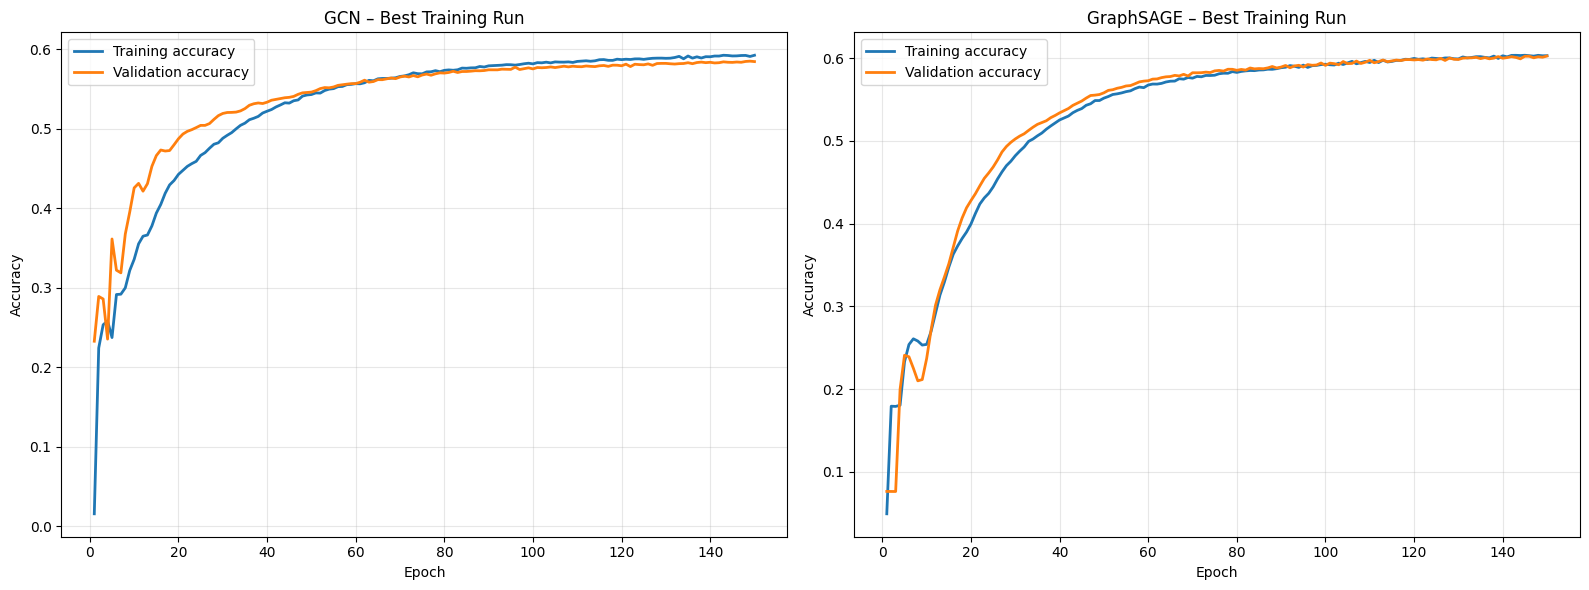

In [12]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

for axis, model_name in zip(
    axes,
    ["GCN", "GraphSAGE"]
):
    history = best_histories[model_name]

    axis.plot(
        history["epoch"],
        history["train_accuracy"],
        label="Training accuracy",
        linewidth=2
    )

    axis.plot(
        history["epoch"],
        history["validation_accuracy"],
        label="Validation accuracy",
        linewidth=2
    )

    axis.set_title(
        f"{model_name} – Best Training Run"
    )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("Accuracy")
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT / "best_model_accuracy_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.9 Training Decisions

Cross-entropy handles the 40-class problem. Adam updates the parameters. Two configurations tune hidden dimension, learning rate, and dropout. Validation accuracy selects the best checkpoint, and early stopping avoids unnecessary training. No advanced scheduler, weighted loss, residual connection, or gradient clipping is used.